## importing librarirs and load data

In [2]:
import numpy as np 
import pandas as pd

import seaborn as sns 
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')



In [22]:
data=pd.read_excel(r"/kaggle/input/online-retail-xlsx/Online Retail.xlsx")

## Data Preprocessing 

In [23]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [44]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### clean data 

In [13]:
data['Quantity'].value_counts()

Quantity
 1        148227
 2         81829
 12        61063
 6         40868
 4         38484
           ...  
-472           1
-161           1
-1206          1
-272           1
-80995         1
Name: count, Length: 722, dtype: int64

In [59]:
data['InvoiceNo'].value_counts()

InvoiceNo
573585     1114
581219      749
581492      731
580729      721
558475      705
           ... 
581483        1
581566        1
C581499       1
C536383       1
C536379       1
Name: count, Length: 25900, dtype: int64

In [51]:
len(data[data['InvoiceNo'].astype(str).str.startswith("C")])

9288

In [53]:
len(data[data['Quantity']<0])

10624

In [54]:
data=data[~data['InvoiceNo'].astype(str).str.startswith("C")] 
data=data[data['Quantity']>=0]

In [55]:
data['InvoiceNo'].value_counts()

InvoiceNo
573585    1114
581219     749
581492     731
580729     721
558475     705
          ... 
572869       1
545675       1
557092       1
545666       1
552194       1
Name: count, Length: 20728, dtype: int64

In [58]:
print(data.duplicated().sum() , "duplicated value")
data = data.drop_duplicates()

5231 duplicated value


### handling missing values

In [61]:
data['CustomerID'].fillna(0, inplace=True)
data.dropna(inplace=True)

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 525462 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    525462 non-null  object        
 1   StockCode    525462 non-null  object        
 2   Description  525462 non-null  object        
 3   Quantity     525462 non-null  int64         
 4   InvoiceDate  525462 non-null  datetime64[ns]
 5   UnitPrice    525462 non-null  float64       
 6   CustomerID   525462 non-null  float64       
 7   Country      525462 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.1+ MB


### Calculate Customer Lifetime Value (CLV): Total spending per customer (Quantity × UnitPrice)

In [100]:
# Calculate Customer Lifetime Value (CLV): Total spending per customer (Quantity × UnitPrice)

data['total_price']=data['Quantity']*data['UnitPrice'] 

data['CLV']=data.groupby('CustomerID')['total_price'].transform('sum')

In [104]:
# this code handle the CLV for guest customers  
for i in df.iloc:
    if i.CustomerID == 0:
        i.CLV = i.total_price

### Create RFM features: 

In [105]:
#create RFM Recency Frequency Monetary features
snapshot_date=data['InvoiceDate'].max()+ pd.Timedelta(days=1)
data['Recency']=data.groupby('CustomerID')['InvoiceDate'].transform(lambda x:(snapshot_date-x.max()).days)

data['Frequency']=data.groupby('CustomerID')['InvoiceNo'].transform('nunique')

data['Monetary']=data.groupby('CustomerID')['total_price'].transform('sum')

In [106]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price,CLV,Recency,Frequency,Monetary
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,5391.21,372,34,5391.21
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,5391.21,372,34,5391.21
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,5391.21,372,34,5391.21
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,5391.21,372,34,5391.21
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,5391.21,372,34,5391.21


# Create Analysis DataFrame

In [248]:
analysisDF = pd.DataFrame({})

In [249]:
analysisDF['ID'] = data.CustomerID.unique()

In [250]:
Customers = data.groupby('CustomerID')

In [256]:
# Create Monetary in for each customer in customer only dataframe
analysisDF = analysisDF.merge(Customers.agg({'total_price':'sum'}),
                 right_on='CustomerID'
                ,left_on = 'ID',
                how='inner')

In [258]:
# Create Frequence in for each customer in customer only dataframe
analysisDF = analysisDF.merge(Customers.agg({'InvoiceNo':'nunique'}),
                 right_on='CustomerID'
                ,left_on = 'ID',
                how='inner')

In [260]:
# Create Recency in for each customer in customer only dataframe

recDf = Customers.agg({'InvoiceDate':'max'}).copy()

recDf['InvoiceDate'] = list(map(lambda x : (snapshot_date - x).days ,recDf.values.reshape(-1)))
analysisDF = analysisDF.merge(recDf,
                 left_on = 'ID',
                 right_on='CustomerID',
                how='inner')

In [285]:
analysisDF.head()

,ID,Monetary,Frequence,Recency
0,17850.0,5391.21,34,372
1,13047.0,3237.54,10,32
2,12583.0,7281.38,15,3
3,13748.0,948.25,5,96
4,15100.0,876.00,3,334


In [262]:
analysisDF.columns = ["ID","Monetary","Frequence","Recency"]

In [228]:
analysisDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         4340 non-null   float64
 1   Monetary   4340 non-null   float64
 2   Frequence  4340 non-null   int64  
 3   Recency    4340 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 135.8 KB


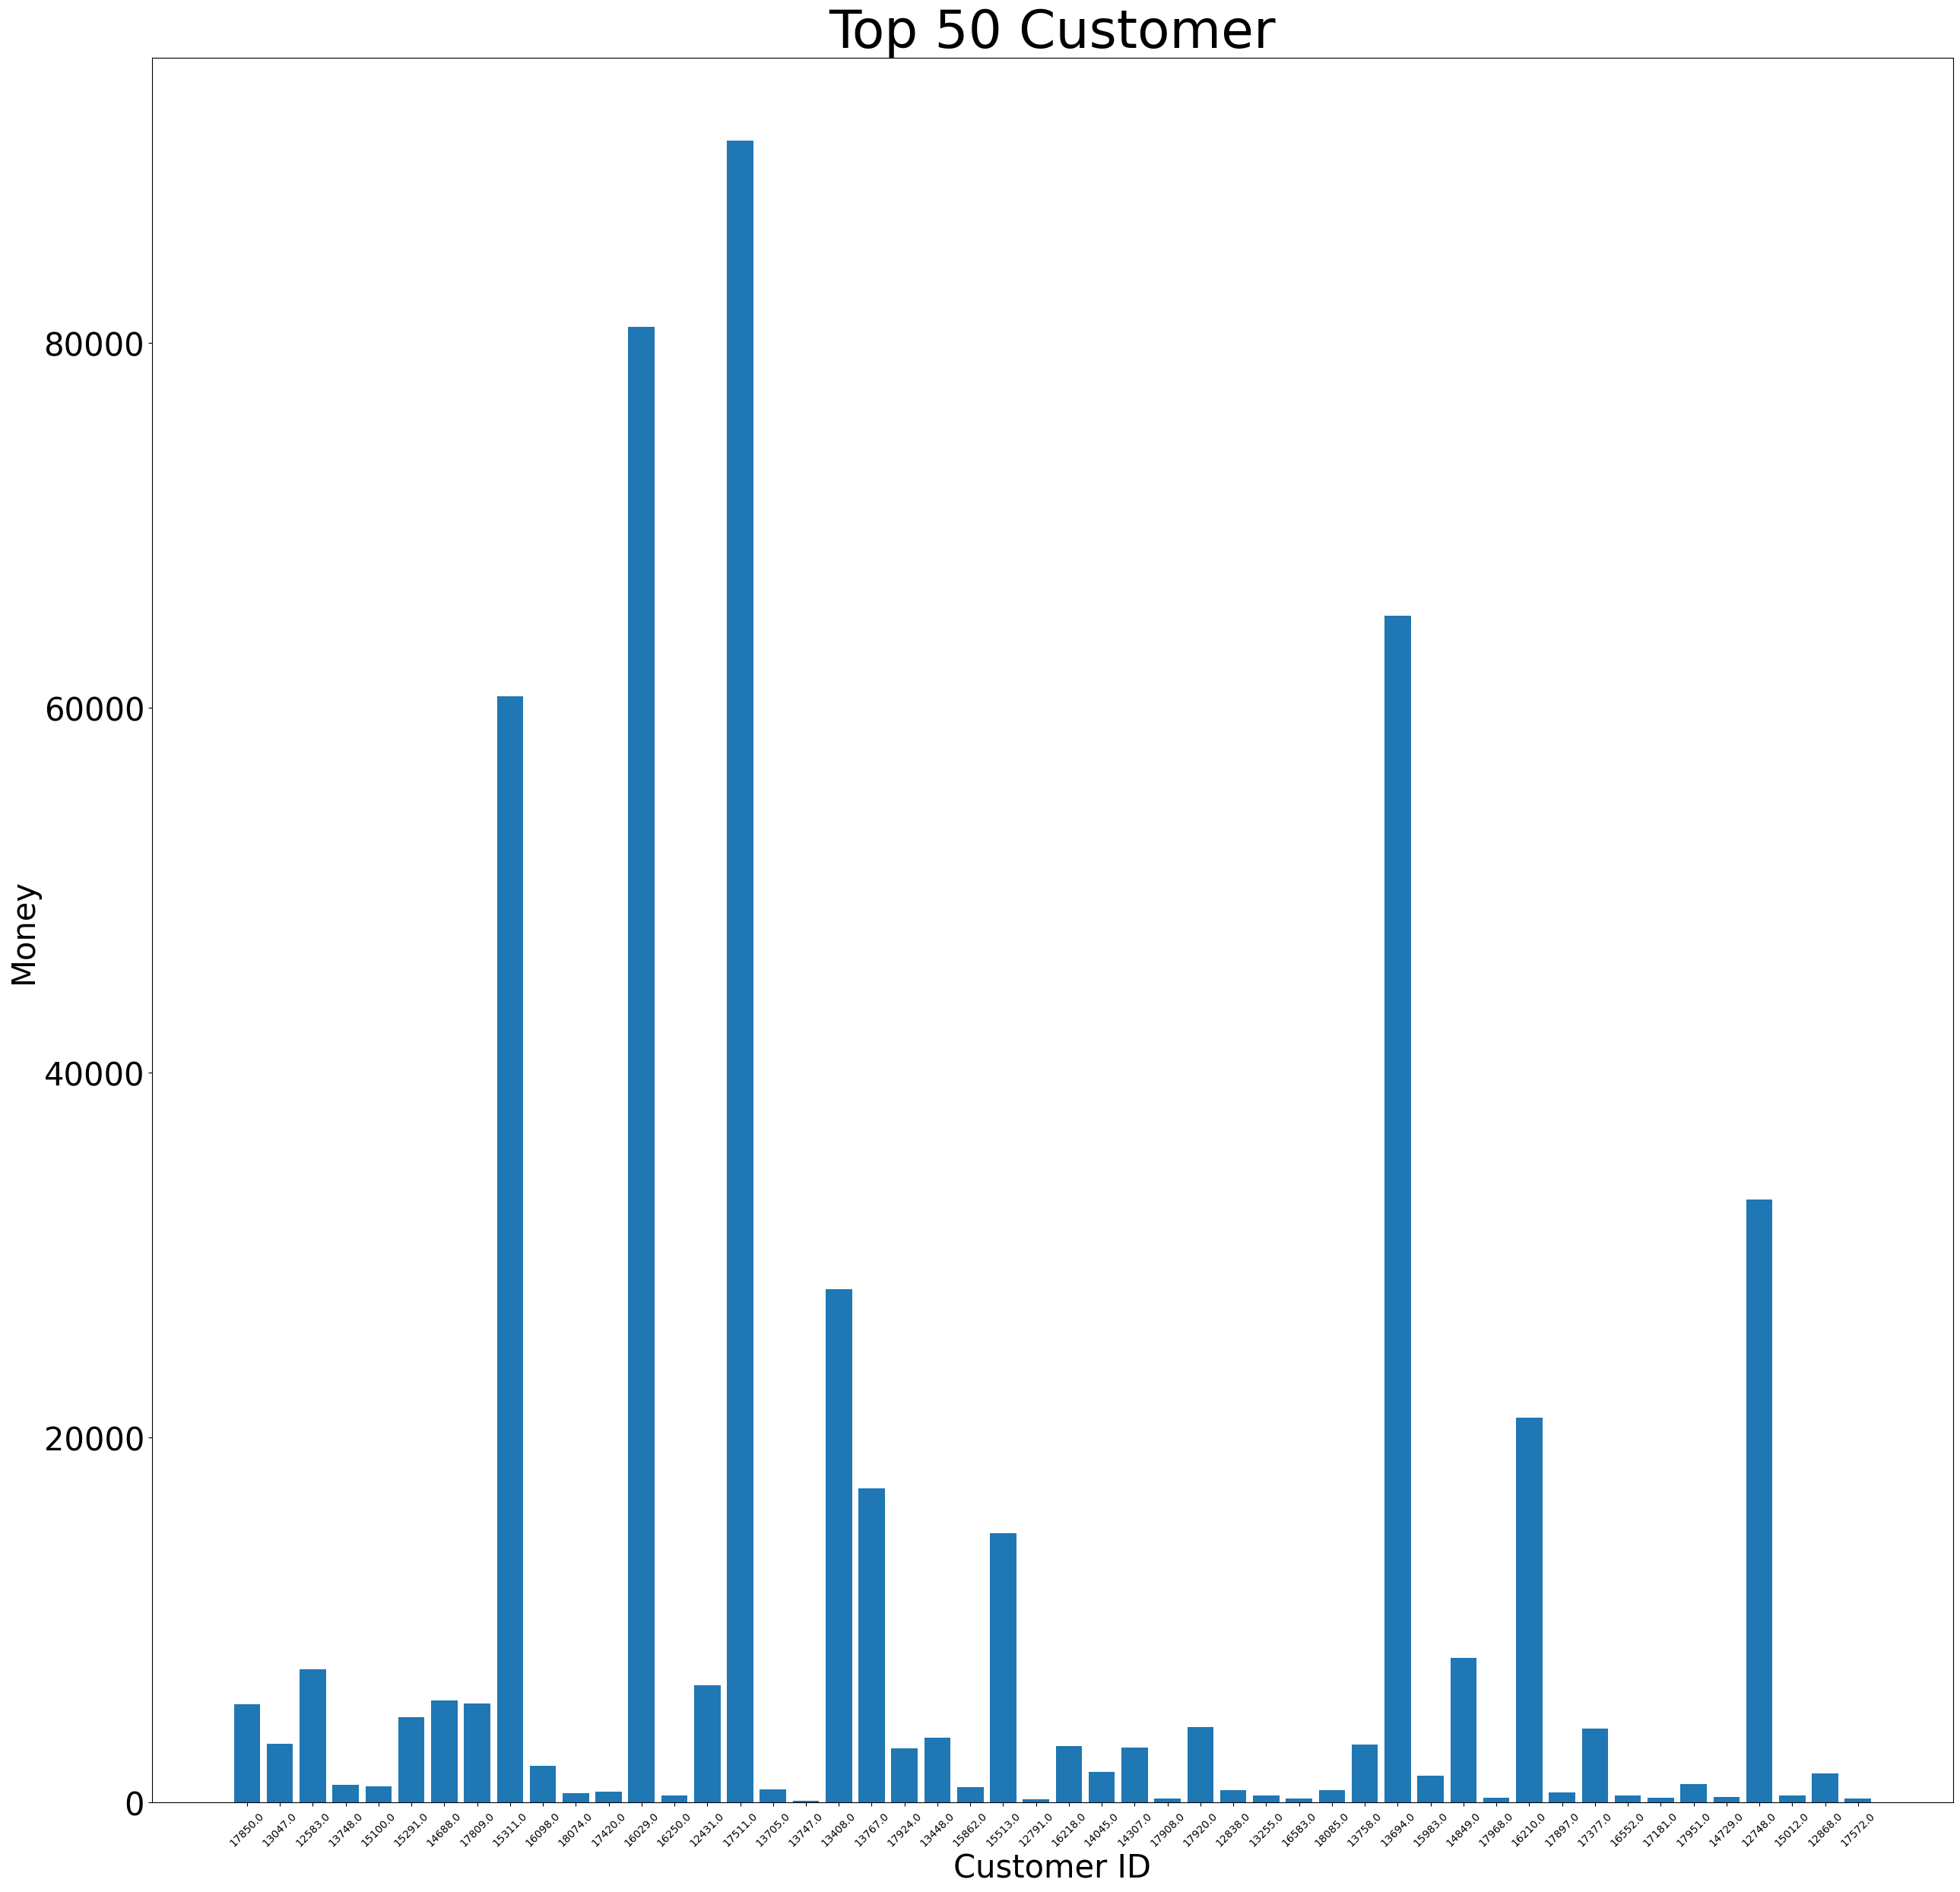

In [284]:
plt.figure(figsize=(25,25))
plt.bar(analysisDF.ID.iloc[:50].astype('str'),
        analysisDF.Monetary.iloc[:50])
plt.xlabel('Customer ID',size=30)
plt.title('Top 50 Customer',size=50)
plt.ylabel('Money',size=30)
plt.xticks(rotation=45,size=10)
plt.tight_layout()
plt.yticks(size=30)
plt.show()

### Engineer temporal features: hour of day, day of week, month, season from InvoiceDate 

In [70]:
#1-hour of day
data['Hour']=data['InvoiceDate'].dt.hour

#2-day of week
data['Day']=data['InvoiceDate'].dt.dayofweek  # 0 = Monday and 1=tuseday ....

#3- month
data['Month']=data['InvoiceDate'].dt.month

#4-season
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else :
        return 'Autum'

data['Season']=data['Month'].apply(get_season)

In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 526054 entries, 0 to 541908
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    526054 non-null  object        
 1   StockCode    526054 non-null  object        
 2   Description  526054 non-null  object        
 3   Quantity     526054 non-null  int64         
 4   InvoiceDate  526054 non-null  datetime64[ns]
 5   UnitPrice    526054 non-null  float64       
 6   CustomerID   526054 non-null  float64       
 7   Country      526054 non-null  object        
 8   total_price  526054 non-null  float64       
 9   CLV          526054 non-null  float64       
 10  Recency      526054 non-null  int64         
 11  Frequency    526054 non-null  int64         
 12  Monetary     526054 non-null  float64       
 13  Hour         526054 non-null  int32         
 14  Day          526054 non-null  int32         
 15  Month        526054 non-null  int32    

In [75]:
data['Hour'].value_counts()

Hour
12    76096
15    75851
13    70067
14    65384
11    55592
16    53074
10    47670
9     33738
17    27498
8      8802
18     7696
19     3428
20      778
7       379
6         1
Name: count, dtype: int64

### Normalize numerical features using StandardScaler

In [77]:
from sklearn.preprocessing import StandardScaler

num_cols=['Quantity','UnitPrice','total_price','CLV','Recency','Frequency','Monetary']
scaler=StandardScaler()
data[num_cols]=scaler.fit_transform(data[num_cols])


### Handle categorical variables: Country, product categories from Description

In [86]:
country_dummies = pd.get_dummies(data['Country'], prefix='Country', drop_first=True)

data = pd.concat([data, country_dummies], axis=1)

In [89]:
data['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     2907
JUMBO BAG RED RETROSPOT                2112
REGENCY CAKESTAND 3 TIER               2009
PARTY BUNTING                          1700
LUNCH BAG RED RETROSPOT                1581
                                       ... 
SET 10 CARDS SNOWY ROBIN 17099            1
SET 10 CARDS SWIRLY XMAS TREE 17104       1
LETTER "U" BLING KEY RING                 1
John Lewis                                1
PAPER CRAFT , LITTLE BIRDIE               1
Name: count, Length: 4077, dtype: int64

In [90]:
# dictionary for each category
category_keywords = {
    "Fashion": ["bag", "dress", "shirt","shoes", "jacket", "coat"],
    "Home": [ "bunting", "holder","candle", "lamp", "light"],
    "Kitchen": ["cakestand", "cup", "mug", "plate", "knife", "fork", "spoon", "kettle", "bottle", "glass"],
    "Stationery": ["card", "craft", "letter","notebook", "pen", "pencil"],
    "Accessories": ["key ring", "bling","jewelry","ring"]
}

# function
def extract_category(text):
    text = str(text).lower()
    for category, keywords in category_keywords.items():
        if any(word in text for word in keywords):
            return category
    return "Other"


data['ProductCategory'] = data['Description'].apply(extract_category)

In [91]:
# encoding ProductCategory
category_dummies = pd.get_dummies(data['ProductCategory'], prefix='ProdCat')
data = pd.concat([data, category_dummies], axis=1)

In [93]:
data['ProductCategory'].value_counts()

ProductCategory
Other          330643
Fashion         54966
Home            48144
Kitchen         44691
Stationery      41288
Accessories      6322
Name: count, dtype: int64